# <font color='blue'>Variational autoencoder (VAE) for MNIST</font>

In this notebook, we explore Variational Autoencoders (VAEs). VAEs are powerful generative models that can learn to encode and decode complex data distributions, making them suitable for tasks like image generation, data denoising, and latent space manipulation. We'll apply them to the MNIST dataset of handwritten digits and demonstrate how to build and train a VAE from scratch.

The VAE is a probabilistic model that learns a compact representation of data while enabling the generation of new data points. It has two components: an <b>encoder</b> network that maps data points to a latent space and a <b>decoder</b> network that generates data points from the latent space representations. VAEs use probabilistic distributions to model the latent space, which allows for sampling and interpolation in this space.

Here's a high-level overview of what we'll cover:

1. Introduction to VAEs: the core concepts behind VAEs, including the probabilistic framework and the objective function.

2. Setting up the MNIST dataset: loading and preprocessing the MNIST dataset, preparing it for training our VAE.

3. Building the VAE architecture: defining the encoder and decoder networks.

4. Training the VAE: training the VAE on the MNIST dataset, by minimizing a particular loss function. 

5. Sampling and generating new images.

6. Visualizing the latent space.

Note: This notebook builds upon code from https://github.com/lyeoni/pytorch-mnist-VAE

## <font color='blue'>Introduction to VAEs</font>

VAEs extend the basic autoencoder concept by introducing a probabilistic framework. Rather than mapping data directly to a fixed point in the latent space, VAEs model the data generation process probabilistically.

The core components of VAEs include:

1. Encoder network: This part of the model maps an input data point to the parameters of a (Gaussian) distribution over the latent space.

2. Reparameterization trick: To make the model differentiable, VAEs use a reparameterization trick, enabling them to sample from the latent distribution without breaking the backpropagation chain. 

3. Decoder network: The decoder network takes a vector in the latent space and generates a point in the data (input) space.

4. Variational loss: VAEs are trained to minimize a loss function composed of two terms: a reconstruction loss, ensuring the generated data resembles the input, and a regularization term encouraging the latent space to follow a particular distribution (usually a standard Gaussian).

## <font color='blue'>Package setup and dataset</font>

In this notebook, we'll be working with the MNIST dataset, a collection of 28x28 grayscale images of handwritten digits from 0 to 9.

In the provided code block, we begin by importing the necessary libraries, including `PyTorch` and `torchvision`, which will help us manage the dataset effortlessly. We also set the batch size `bs` to 100 for our data loader, which determines how many samples are processed in each training iteration.

Next, we use torchvision to download and preprocess the MNIST dataset. The dataset is automatically downloaded, transformed into PyTorch tensors, and loaded into memory. We shuffle the data by setting `shuffle=True` in the data loader.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms,datasets
from torch.utils.data import DataLoader
from torchvision.utils import save_image,make_grid
from torchinfo import summary
from matplotlib import pyplot as plt

In [2]:
# Batch size for training
bs = 100
# Loader for training set
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=bs, shuffle=True)
# For this notebook 'cpu' should be fine
device = 'cuda' if torch.cuda.is_available() else 'cpu'

100%|██████████| 9.91M/9.91M [00:22<00:00, 449kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 284kB/s]
100%|██████████| 1.65M/1.65M [00:07<00:00, 230kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.04MB/s]


Let's look at the first five images (data points) returned by the data loader.

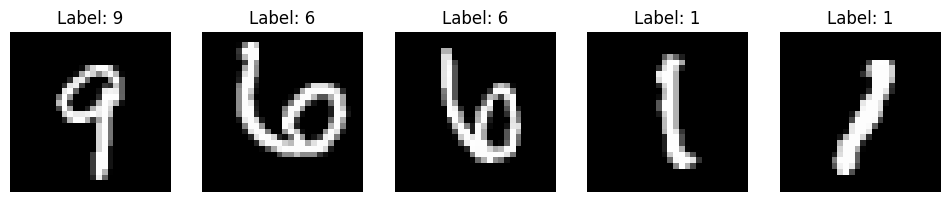

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, (image, label) in enumerate(train_loader):
    if i >= 5:
        break
    ax = axes[i]
    ax.imshow(image[0, 0], cmap='gray')
    ax.set_title(f"Label: {label[0].item()}")
    ax.axis('off')
plt.show()

## <font color='blue'>Defining the VAE</font>

In this section, we define the VAE architecture. There is an encoder network responsible for mapping input data to a latent space, a decoder network for generating data from latent space representations, and additional layers to facilitate the probabilistic framework of VAEs.

The VAE class is implemented as a PyTorch module and is initialized with two crucial parameters: `x_dim` and `z_dim`. These parameters represent the dimensions of the input data and the latent space, respectively.

Here's a breakdown of the components of the VAE class:

1. Encoder network: This has two fully connected layers (`downsize_1` and `downsize_2`) that reduce the dimensionality of the input data. The output of these layers is then split into two branches, with one branch predicting the mean (`mu_fc`) and the other branch predicting the log variance (`log_var_fc`) of the distribution over the latent space.

2. Sampling function: The sampling method generates samples from the latent space using the reparameterization trick. It takes the predicted mean and log variance, transforms the log variance into standard deviation, and samples random noise to create the latent code.

3. Decoder network: The decoder network reverses the process by mapping the latent space back to the data space. It consists of three fully connected layers (`upsize_1`, `upsize_2`, and `upsize_3`) that progressively increase the dimensionality.

4. Forward method: In the forward method, we connect the encoder, sampling, and decoder to create a complete forward pass. Given an input `x`, it first uses the encoder to compute the mean and log variance of a Gaussian distribution over the latent space. It then samples from the latent space and feeds this sample to the decoder to produce a reconstruction of the input data. The method also returns the mean and log variance for later use during training.

We'll proceed to train this VAE and generate new images in the upcoming sections.

In [4]:
class VAE(nn.Module):
    def __init__(self, x_dim, z_dim):
        super(VAE, self).__init__()
        
        self.downsize_1 = nn.Linear(x_dim, 512)
        self.downsize_2 = nn.Linear(512, 256)
        self.mu_fc = nn.Linear(256, z_dim)
        self.log_var_fc = nn.Linear(256, z_dim)
        
        self.upsize_1 = nn.Linear(z_dim, 256)
        self.upsize_2 = nn.Linear(256, 512)
        self.upsize_3 = nn.Linear(512, x_dim)
        
    def encoder(self, x):
        h = nn.functional.relu(self.downsize_1(x))
        h = nn.functional.relu(self.downsize_2(h))
        return self.mu_fc(h), self.log_var_fc(h) 
    
    def sampling(self, mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu) 
        
    def decoder(self, z):
        h = nn.functional.relu(self.upsize_1(z))
        h = nn.functional.relu(self.upsize_2(h))
        return nn.functional.sigmoid(self.upsize_3(h)) 
    
    def forward(self, x):
        mu, log_var = self.encoder(x.view(-1, 784))
        z = self.sampling(mu, log_var)
        return self.decoder(z), mu, log_var

## <font color='blue'>Training the VAE</font>

The first step is to define the loss function.

### <font color='blue'>The loss function</font>

The loss function for VAEs balances reconstruction quality with regularization of the latent space.

The `loss_function` defined in this code block plays a pivotal role in training our VAE. It has two components:

- Binary cross-entropy loss (BCE): measures the dissimilarity between the reconstructed data and the original input. It quantifies how well the VAE does at reproducing the input data. We use the `nn.BCELoss` function with the `reduction='sum'` argument to compute the BCE loss. It compares the reconstructed data (`recon_x`) and the input data (`x.view(-1, 784)`) element-wise.

- Kullback-Leibler divergence (KLD): regularizes the latent space. It encourages the distribution of the latent variables (encoded by `mu` and `logvar`) to be as close as possible to a standard Gaussian distribution. The formula used here is the Kullback-Leibler divergence, which quantifies the difference between two probability distributions. 

The total loss is the sum of the `BCE` and `KLD` terms. This combination of terms results in the Evidence Lower Bound (ELBO), which we aim to maximize during training. Maximizing the ELBO is equivalent to maximizing the likelihood of the data under the model while regularizing the latent space.


In [5]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.BCELoss(reduction='sum')(recon_x, x.view(-1,784))
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In this section, we configure some crucial parameters for the VAE model and for training.


- Latent dimension (`latent_dim`): dimensionality of the latent space in our VAE. In this example, we set it to 8, but you can adjust it depending on the complexity of the dataset and the desired level of data compression.

- Model initialization: We create an instance of our VAE model by calling `VAE(x_dim=784, z_dim=latent_dim)`. This step initializes the VAE architecture. The `x_dim` is set to `784`, corresponding to the dimensionality of the input data (28x28 images flattened to 784 pixels).

- Optimizer initialization: We train with the Adam optimizer, a popular choice for deep learning models. The `optim.Adam` function is used to initialize the optimizer, and it is provided with the model's parameters. The optimizer will be responsible for adjusting the model's weights during training to minimize the defined loss function.

In [6]:
# Key parameter: dimension of latent space
latent_dim = 8

model = VAE(x_dim=784,z_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters())

### <font color='blue'>The training procedure</font>

This next cell trains the VAE for a specified number of epochs.

You don't need to run the cell at this point since we have already done it for two choices of `latent_dim` (dimension of `z`): 2 and 8. These models are stored in the files `vae_mnist_z_2.pth` and `vae_mnist_z_8.pth`.


In [ ]:
#
# NO NEED TO RUN THIS CELL UNLESS YOU WANT TO TRAIN YOUR OWN MODEL
#
num_epochs = 50 # number of epochs of training
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        recon_data, mu, logvar = model(data)
        loss = loss_function(recon_data, data, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print("Epoch {} Loss : {:.4f}".format(epoch, epoch_loss / len(train_dataset)))
# Save learned model
torch.save(model.state_dict(), 'vae_mnist_z_{}.pth'.format(latent_dim))

## <font color='blue'>Loading the pre-trained model</font>

With a pretrained VAE model loaded, you can now perform various tasks, such as generating new images, exploring the latent space, or evaluating the model's performance on different datasets.

First, let's load a model (for a specified `latent_dim`) and print a summary.

In [8]:
latent_dim = 2
model_test = VAE(x_dim=784,z_dim=latent_dim).to(device)
model_test.load_state_dict(torch.load('vae_mnist_z_{}.pth'.format(latent_dim),map_location=torch.device('cpu')))
summary(model_test, input_size=(100, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [100, 784]                --
├─Linear: 1-1                            [100, 512]                401,920
├─Linear: 1-2                            [100, 256]                131,328
├─Linear: 1-3                            [100, 2]                  514
├─Linear: 1-4                            [100, 2]                  514
├─Linear: 1-5                            [100, 256]                768
├─Linear: 1-6                            [100, 512]                131,584
├─Linear: 1-7                            [100, 784]                402,192
Total params: 1,068,820
Trainable params: 1,068,820
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 106.88
Input size (MB): 0.31
Forward/backward pass size (MB): 1.86
Params size (MB): 4.28
Estimated Total Size (MB): 6.45

## <font color='blue'>Generating images from the VAE</font>

In this section, we use the VAE to generate new MNIST-like samples.

We pick 100 random vectors in the latent space (of dimension `latent_dim`), each from a standard Gaussian distribution. This random sampling allows us to observe the diversity of images that the VAE can generate.

For each of these random latent vectors, we use our decoder (`model_test.decoder`) to generate a corresponding image in the usual (784-dimensional) MNIST space. These images are saved in the folder `samples` for later inspection.

In [9]:
with torch.no_grad():
    random_sample = torch.randn(100,latent_dim)
    generated_image = model_test.decoder(random_sample.to(device))
    save_image(generated_image.view(100,1,28,28),'./samples/random_sample_z_{}.png'.format(latent_dim), nrow=10)

Now let's view the random samples

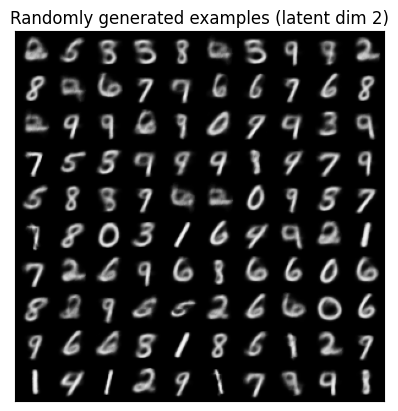

In [10]:
img = plt.imread('./samples/random_sample_z_{}.png'.format(latent_dim))
plt.title('Randomly generated examples (latent dim {})'.format(latent_dim))
plt.tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False)
plt.imshow(img)
plt.show()

In [ ]:
# train with latent_dim = 4
latent_dim = 4  # CHANGED FROM 8 TO 4
model = VAE(x_dim=784, z_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters())

print(f"Training VAE with latent_dim={latent_dim}...")
num_epochs = 10 
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_data, mu, logvar = model(data)
        loss = loss_function(recon_data, data, mu, logvar)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {epoch_loss / len(train_dataset):.4f}")

# save the model
torch.save(model.state_dict(), f'vae_mnist_z_{latent_dim}.pth')

# 4. generate 100 Samples
with torch.no_grad():
    # Sample 100 latent vectors from N(0, I)
    random_sample = torch.randn(100, latent_dim).to(device)
    # Decode them
    generated_image = model.decoder(random_sample)
    # Save as a 10x10 grid
    save_image(generated_image.view(100, 1, 28, 28), 
               f'samples_z_{latent_dim}.png', nrow=10)
    print(f"Saved generated samples to samples_z_{latent_dim}.png")



Training VAE with latent_dim=4...
Epoch 1 Loss: 166.7313
Epoch 2 Loss: 137.4466
Epoch 3 Loss: 132.7513
Epoch 4 Loss: 130.0187
Epoch 5 Loss: 128.1094
Epoch 6 Loss: 126.6860
Epoch 7 Loss: 125.4572
Epoch 8 Loss: 124.5662
Epoch 9 Loss: 123.6796
Epoch 10 Loss: 122.9129
Saved generated samples to samples_z_4.png


FileNotFoundError: [Errno 2] No such file or directory: './samples/random_sample_z_4.png'

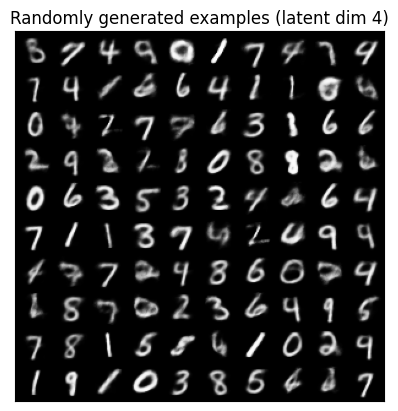

In [14]:
img = plt.imread('./samples/samples_z_{}.png'.format(latent_dim))
plt.title('Randomly generated examples (latent dim {})'.format(latent_dim))
plt.tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False)
plt.imshow(img)
plt.show()

## <font color='blue'>Further exploration of the latent space</font>

Next, we explore the latent space a bit more closely.

This next cell generates 20 large image files, each containing a grid of 256 images. Each of the large files is produced in the following way:
- We pick two random points in the latent space (of dimension `latent_dim`). Think of one as the starting point and the other as the ending point.
- We move in the latent space from the starting point to the ending point. Specifically, we generate 256 vectors spaced evenly on the line segment joining the starting and ending points.
- For each of these 256 latent vectors, we use our decoder (`model_test.decoder`) to generate a corresponding image in the usual 784-dimensional MNIST space.
- We thus get a sequence of 256 images in MNIST space and we save them in a 16-by-16 grid. 

This process is repeated 20 times, and the resulting large images are stored in the `.\samples` folder.

In [ ]:
num_steps = 256
with torch.no_grad():
    for idx in range(20):
        # Pick a random start point and end point in the latent space
        start_point = torch.randn(1, latent_dim) 
        end_point = torch.randn(1, latent_dim)

        # Now look at num_steps points spaced evenly on the line between
        # the starting and ending points and generate an image from each 
        # of these latent vectors. Save the resulting chain of images.
        interpolated_points = torch.stack([start_point + (i / (num_steps - 1)) * (end_point - start_point) for i in range(num_steps)])
        generated_image = model_test.decoder(interpolated_points.to(device))
        save_image(generated_image.view(num_steps,1,28,28),'./samples/latent_exploration_z_{}_{}.png'.format(latent_dim,idx), nrow=int(num_steps**0.5))

Now let's take a look at the first of these 20 images.

In [ ]:
img = plt.imread('./samples/latent_exploration_z_{}_1.png'.format(latent_dim))
plt.title('Latent space exploration (latent dim {})'.format(latent_dim))
plt.tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False)
plt.imshow(img)
plt.show()

Saved ./samples/latent_exploration_z_4_1.png
Saved ./samples/latent_exploration_z_4_2.png


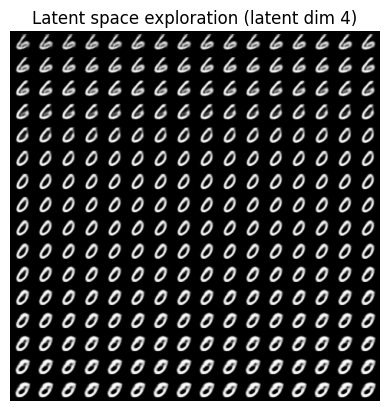

In [ ]:
import torch
from torchvision.utils import save_image
import matplotlib.pyplot as plt

# Set latent dim and number of steps
latent_dim = 4
num_steps = 256  
model.eval()     

with torch.no_grad():
    # Change range(20) to range(2) to get exactly 2 images
    for idx in range(2):
        # 1. Pick random start and end points
        start_point = torch.randn(1, latent_dim).to(device)
        end_point = torch.randn(1, latent_dim).to(device)

        # 2. Interpolate 256 points between start and end
        # This creates a smooth transition vector
        alphas = torch.linspace(0, 1, num_steps).to(device).unsqueeze(1).unsqueeze(2)
        interpolated_points = start_point + alphas * (end_point - start_point)
        # Note: shape is [256, 1, 4]

        # 3. Decode these points into images
        generated_image = model.decoder(interpolated_points)
        
        # 4. Save the grid
        # nrow=16 makes it a square 16x16 grid
        filename = f'./samples/latent_exploration_z_{latent_dim}_{idx+1}.png'
        save_image(generated_image.view(num_steps, 1, 28, 28), 
                   filename, nrow=16)
        print(f"Saved {filename}")

# Display the first one to check
img = plt.imread(f'./samples/latent_exploration_z_{latent_dim}_1.png')
plt.title(f'Latent space exploration (latent dim {latent_dim})')
plt.axis('off')
plt.imshow(img)
plt.show()

### q2 a

In [16]:
import numpy as np
import nltk
from collections import Counter
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# 1. Setup Data
print("Downloading corpus...")
nltk.download('brown') # Using the Brown corpus (1M words)
from nltk.corpus import brown

# 2. Vocabulary & Context Selection
print("Building vocabulary...")
words = [w.lower() for w in brown.words() if w.isalpha()]
vocab_size = 5000
word_counts = Counter(words)
# V: Top 5000 most frequent words
vocab = [w for w, c in word_counts.most_common(vocab_size)]
word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}

# 3. Build Co-occurrence Matrix
print("Building co-occurrence matrix...")
window_size = 2 # Context is +/- 2 words
cooc_mat = np.zeros((vocab_size, vocab_size))

for i in range(len(words)):
    target = words[i]
    if target not in word_to_id: continue
    target_id = word_to_id[target]
    
    # Check context window
    start = max(0, i - window_size)
    end = min(len(words), i + window_size + 1)
    
    for j in range(start, end):
        if i == j: continue
        context = words[j]
        if context in word_to_id:
            context_id = word_to_id[context]
            cooc_mat[target_id, context_id] += 1

# 4. Convert to PPMI (Positive Pointwise Mutual Information)
print("Calculating PPMI...")
total_count = np.sum(cooc_mat)
row_sums = np.sum(cooc_mat, axis=1)
col_sums = np.sum(cooc_mat, axis=0)

# P(w, c), P(w), P(c)
P_wc = cooc_mat / total_count
P_w = row_sums / total_count
P_c = col_sums / total_count

# PMI = log( P(w,c) / (P(w)*P(c)) )
# We use a small epsilon to avoid log(0)
epsilon = 1e-12
# Broadcasting division for efficiency
expected = np.outer(P_w, P_c)
pmi_mat = np.log((P_wc + epsilon) / (expected + epsilon))
ppmi_mat = np.maximum(pmi_mat, 0) # ReLU for PMI

# 5. SVD Reduction to 100 dimensions
print("Performing SVD...")
k = 100
# Usage of sparse SVD (svds)
U, S, Vt = svds(csr_matrix(ppmi_mat), k=k)
# Embeddings: U * sqrt(S) is a common choice, or just U
embeddings = U @ np.diag(np.sqrt(S))
# Normalize for cosine similarity
embeddings = normalize(embeddings)

[nltk_data] Downloading package brown to /home/scotty/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


Building vocabulary...
Building co-occurrence matrix...
Calculating PPMI...
Performing SVD...


In [17]:
import numpy as np
import nltk
from collections import Counter
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# --- Q2(b) Nearest Neighbors ---
print("\n--- Nearest Neighbors ---")
test_words = ['government', 'school', 'music', 'war', 'book']
for w in test_words:
    if w in word_to_id:
        idx = word_to_id[w]
        vec = embeddings[idx].reshape(1, -1)
        sims = cosine_similarity(vec, embeddings)[0]
        # Sort descending, skip self (index 0 is self)
        closest_idx = np.argsort(sims)[::-1][1] 
        print(f"{w} -> {id_to_word[closest_idx]}")



--- Nearest Neighbors ---
government -> federal
school -> college
music -> poetry
war -> world
book -> story


In [18]:
# --- Q2(c) Clustering ---
print("\n--- Clustering ---")
kmeans = KMeans(n_clusters=100, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

# Print a few clusters
for i in range(5):
    cluster_words = [id_to_word[j] for j in range(vocab_size) if labels[j] == i]
    # Print first 10 words of the cluster
    print(f"Cluster {i}: {', '.join(cluster_words[:10])}")


--- Clustering ---
Cluster 0: though, almost, yet, word, words, together, sound, alone, fine, immediately
Cluster 1: while, making, except, taking, using, filled, giving, goes, selected, starting
Cluster 2: wanted, doing, thinking, saying, meant, knows, seeing, remembered, agreed, believed
Cluster 3: power, interest, kind, sense, experience, real, love, value, spirit, hope
Cluster 4: sure, happened, yes, maybe, wrong, lot, oh, exactly, bit, hell
